In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

def setup_date_axis(ax, interval_days=1):
    """Вспомогательная функция для настройки оси дат (дневной масштаб)"""
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=interval_days))
    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

def normalize_timezone(df, column_name):
    """Приводит колонку с датами к timezone-naive (убирает UTC)"""
    if df[column_name].dt.tz is not None:
        df[column_name] = df[column_name].dt.tz_localize(None)
    return df

def aggregate_votes_by_day(votes_df, date_column, vote_columns, start_date, end_date):
    """
    Агрегирует голоса по дням
    
    Parameters:
    - votes_df: DataFrame с голосами
    - date_column: имя колонки с датой
    - vote_columns: список колонок для суммирования (например, ['positive_votes', 'important_votes'])
    - start_date, end_date: даты фильтрации
    """
    votes_df = normalize_timezone(votes_df.copy(), date_column)
    
    # Фильтрация по датам
    mask = (votes_df[date_column] >= start_date) & (votes_df[date_column] <= end_date)
    filtered_df = votes_df.loc[mask].copy()
    
    if filtered_df.empty:
        return pd.DataFrame(columns=['date', 'total_votes'])
    
    # Суммируем указанные колонки
    filtered_df['total_votes'] = filtered_df[vote_columns].sum(axis=1)
    filtered_df['date'] = filtered_df[date_column].dt.date
    daily_votes = filtered_df.groupby('date')['total_votes'].sum().reset_index()
    daily_votes['date'] = pd.to_datetime(daily_votes['date'])
    
    return daily_votes

def plot_price_chart(candles_df, start_date, end_date):
    candles_df = normalize_timezone(candles_df.copy(), 'Open time')
    mask = (candles_df['Open time'] >= start_date) & (candles_df['Open time'] <= end_date)
    filtered_df = candles_df.loc[mask].copy()
    
    if filtered_df.empty:
        print("Нет данных о ценах для выбранного периода.")
        return

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(filtered_df['Open time'], filtered_df['High'], color='blue', marker='o', 
            markersize=4, label='Максимальная цена за день', linewidth=2)
    ax.set_xlabel('Дата')
    ax.set_ylabel('Цена', color='blue')
    ax.tick_params(axis='y', labelcolor='blue')
    setup_date_axis(ax, interval_days=1)
    plt.title('Максимальная цена за день')
    plt.grid(True, linestyle='--', alpha=0.7, axis='both')
    plt.tight_layout()
    plt.show()

def plot_votes_chart(daily_votes, vote_type='positive'):
    """
    График голосов по типу
    
    Parameters:
    - daily_votes: DataFrame с агрегированными данными (date, total_votes)
    - vote_type: 'positive' или 'negative'
    """
    if daily_votes.empty:
        print("Нет данных для графика голосов.")
        return
    
    color = 'green' if vote_type == 'positive' else 'red'
    title = 'Позитивные голоса' if vote_type == 'positive' else 'Негативные голоса'

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(daily_votes['date'], daily_votes['total_votes'], width=0.8, alpha=0.7, 
           color=color, label=f'Сумма голосов за день ({vote_type})')
    ax.plot(daily_votes['date'], daily_votes['total_votes'], color=color, linestyle='--', 
            linewidth=2, marker='o', markersize=4, label='Тренд голосов')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Голоса', color=color)
    ax.tick_params(axis='y', labelcolor=color)
    setup_date_axis(ax, interval_days=1)
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.7, axis='both')
    plt.tight_layout()
    plt.show()

def plot_combined_charts(candles_df, bull_votes_df, bear_votes_df, start_date, end_date):
    """
    Комбинированный график с тремя метриками
    
    Parameters:
    - candles_df: DataFrame с ценами (колонки: 'Open time', 'High')
    - bull_votes_df: DataFrame с позитивными голосами (колонки: 'datetime', 'positive_votes', 'important_votes')
    - bear_votes_df: DataFrame с негативными голосами (колонки: 'datetime', 'negative_votes', 'important_votes')
    - start_date, end_date: даты фильтрации
    """
    # Агрегация позитивных голосов по дням
    daily_bull = aggregate_votes_by_day(
        bull_votes_df, 
        'datetime', 
        ['positive_votes', 'important_votes'], 
        start_date, 
        end_date
    )
    
    # Агрегация негативных голосов по дням
    daily_bear = aggregate_votes_by_day(
        bear_votes_df, 
        'datetime', 
        ['negative_votes', 'important_votes'], 
        start_date, 
        end_date
    )
    
    # Фильтрация цен
    candles_df = normalize_timezone(candles_df.copy(), 'Open time')
    candles_mask = (candles_df['Open time'] >= start_date) & (candles_df['Open time'] <= end_date)
    filtered_candles = candles_df.loc[candles_mask].copy()
    
    if filtered_candles.empty and daily_bull.empty and daily_bear.empty:
        print("Нет данных для выбранного периода.")
        return
    
    # Создание графика с тремя осями Y
    fig, ax1 = plt.subplots(figsize=(16, 8))
    
    # === Ось 1: Цена (синяя) ===
    if not filtered_candles.empty:
        ax1.plot(filtered_candles['Open time'], filtered_candles['High'], color='blue', 
                 marker='o', markersize=4, label='Макс. цена за день', linewidth=2, zorder=3)
        ax1.set_ylabel('Цена', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
    else:
        ax1.set_ylabel('Цена (нет данных)', color='gray')
    
    # === Ось 2: Позитивные новости (зеленая) ===
    ax2 = ax1.twinx()
    if not daily_bull.empty:
        ax2.bar(daily_bull['date'], daily_bull['total_votes'], width=0.8, alpha=0.4, 
                color='green', label='Позитивные новости', zorder=1)
        ax2.plot(daily_bull['date'], daily_bull['total_votes'], color='green', 
                 linestyle='--', linewidth=2, marker='o', markersize=4, 
                 label='Позитивные (тренд)', zorder=2)
        ax2.set_ylabel('Позитивные новости', color='green')
        ax2.tick_params(axis='y', labelcolor='green')
    else:
        ax2.set_ylabel('Позитивные (нет данных)', color='gray')
    
    # === Ось 3: Негативные новости (красная) ===
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))  # Сдвигаем ось вправо
    
    if not daily_bear.empty:
        ax3.bar(daily_bear['date'], daily_bear['total_votes'], width=0.8, alpha=0.4, 
                color='red', label='Негативные новости', zorder=1)
        ax3.plot(daily_bear['date'], daily_bear['total_votes'], color='red', 
                 linestyle='--', linewidth=2, marker='s', markersize=4, 
                 label='Негативные (тренд)', zorder=2)
        ax3.set_ylabel('Негативные новости', color='red')
        ax3.tick_params(axis='y', labelcolor='red')
    else:
        ax3.set_ylabel('Негативные (нет данных)', color='gray')
    
    # Настройка оси X (общая для всех графиков)
    setup_date_axis(ax1, interval_days=1)
    
    # Легенда (объединяем все три оси)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    
    all_lines = lines1 + lines2 + lines3
    all_labels = labels1 + labels2 + labels3
    
    if all_lines:
        ax1.legend(all_lines, all_labels, loc='upper left')
    
    plt.title('Сравнение цен и активности новостей (по дням)')
    plt.grid(True, linestyle='--', alpha=0.3, axis='both')
    plt.tight_layout()
    plt.show()



✓ Загружены данные:
  - Цены: 2962 записей
  - Позитивные новости: 1000 записей
  - Негативные новости: 1000 записей

Диапазон: 2025-02-16 - 2025-04-16
Часовой пояс данных (цены): UTC
Часовой пояс данных (новости bull): None
Часовой пояс данных (новости bear): None


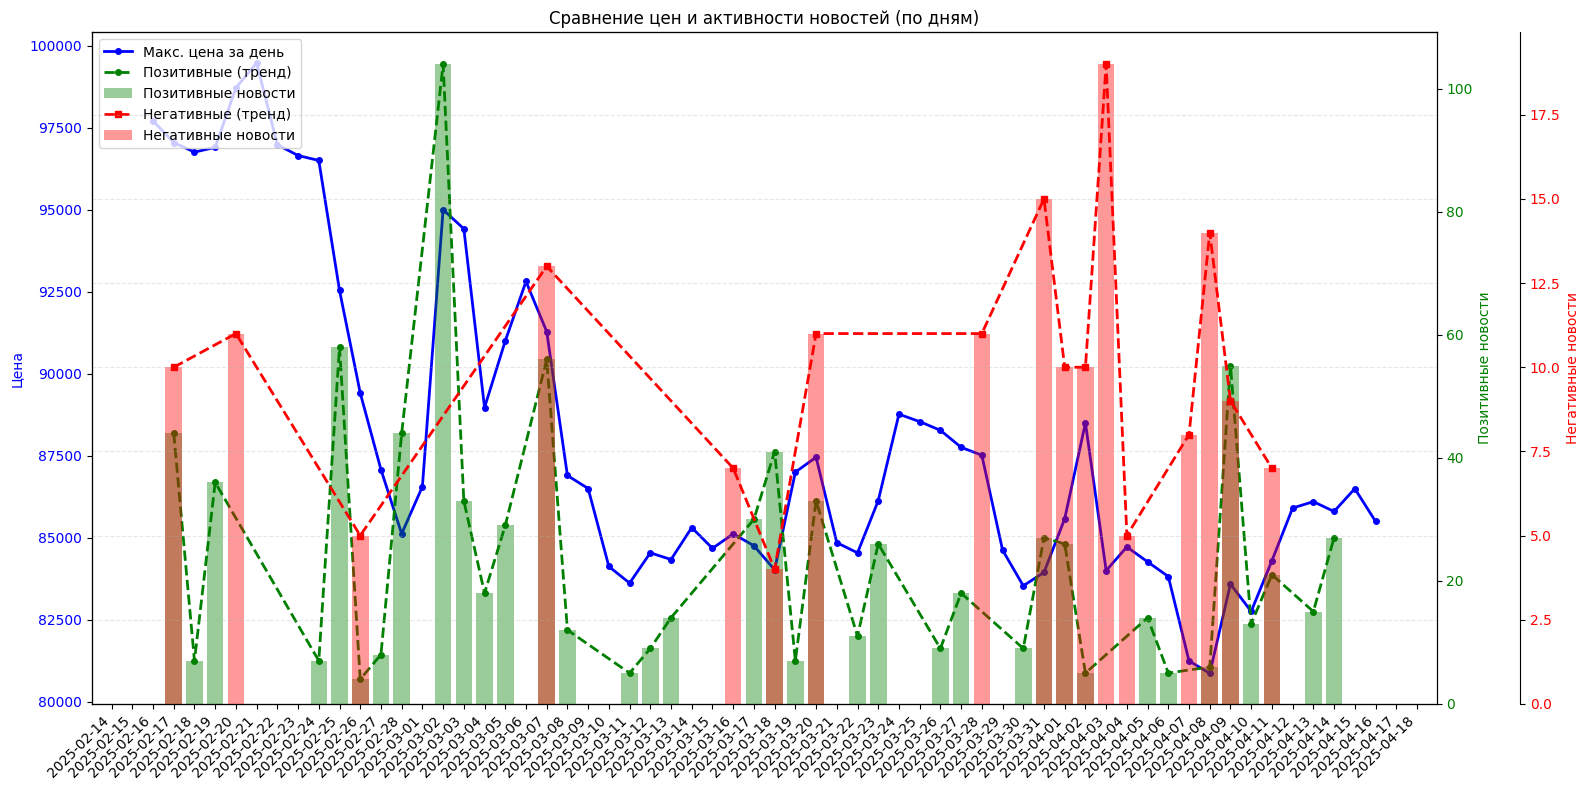

In [4]:
from constants import DATA_BTC_DAY_PATH, DATA_BULL_PATH, DATA_BEAR_PATH

candles_df = pd.read_csv(DATA_BTC_DAY_PATH, parse_dates=['Open time'])
bull_votes_df = pd.read_csv(DATA_BULL_PATH, parse_dates=['datetime'])
bear_votes_df = pd.read_csv(DATA_BEAR_PATH, parse_dates=['datetime'])

print(f"✓ Загружены данные:")
print(f"  - Цены: {len(candles_df)} записей")
print(f"  - Позитивные новости: {len(bull_votes_df)} записей")
print(f"  - Негативные новости: {len(bear_votes_df)} записей")

# Даты для фильтрации
start_date_str = "2025-02-16"
end_date_str = "2025-04-16"

# Используем pd.to_datetime для надежного парсинга (включая микросекунды если есть)
start_date = pd.to_datetime(start_date_str)
end_date = pd.to_datetime(end_date_str)

print(f"\nДиапазон: {start_date.date()} - {end_date.date()}")
print(f"Часовой пояс данных (цены): {candles_df['Open time'].dt.tz}")
print(f"Часовой пояс данных (новости bull): {bull_votes_df['datetime'].dt.tz}")
print(f"Часовой пояс данных (новости bear): {bear_votes_df['datetime'].dt.tz}")

# Построение комбинированного графика
plot_combined_charts(candles_df, bull_votes_df, bear_votes_df, start_date, end_date)
